# 05 - Duration-Matched Quantitative Evaluation

This notebook is the one-audio smoke test for the full quantitative protocol. It uses the same IEMOCAP utterance as the earlier notebooks, `Ses01F_impro01_F005`, and runs the exact library code used by the full dataset script.

The evaluation question is: when SpeechXAI/Pastor top-k words define a masked duration `X`, which HuBERT temporal explanation modes produce the largest target-confidence drop when they are allowed to silence the same duration `X`?

## Protocol Plan

1. Load the HuBERT emotion classifier and classify the original waveform.
2. Use the original predicted class as the target class for every method.
3. Use SpeechXAI/Pastor word alignment through WhisperX.
4. Compute leave-one-out word scores by silencing one effective word interval at a time.
5. For each `k`, let the union duration of the top-k SpeechXAI word masks define `X`.
6. Silence the same duration `X` for every HuBERT temporal relevance mode.
7. Run the **random deletion by silence masking** baseline: choose random fixed-duration audio bins, zero those samples, and preserve waveform length.
8. Compare target-confidence drop, relative drop, and prediction flips.

The full script applies the same logic to all selected IEMOCAP and RAVDESS audios.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.common import MODEL_CLASS_NAMES
from src.evaluation.duration_matched_speechxai import (
    DEFAULT_TOP_K_VALUES,
    AudioEvaluationExample,
    SpeechXAITranscriber,
    classify_waveform,
    disable_huggingface_symlink_cache_on_windows,
    evaluate_duration_matched_audio,
    summarize_duration_matched_records,
    words_to_timing_table,
)
from src.evaluation.iemocap import collect_iemocap_records
from src.explainers.transformer_relevance.legrad_hubert import (
    LEGRAD_LAYER_LOCAL_SCORE_HUBERT_WEIGHTED_SOURCE_TOKENS,
)
from src.explainers.transformer_relevance.score_pipeline import EXPLANATION_MODES
from src.explainers.transformer_relevance.visualization import (
    plot_relevance_timeline,
    plot_waveform_with_interval_scores,
)
from src.models.load_model import load_hubert_emotion_model
from src.speech_xai_project.config import load_config, project_path
from src.utils.audio import load_audio_mono_16k

config = load_config(PROJECT_ROOT / "configs" / "default.yaml")
speechxai_config = config["speechxai"]
evaluation_config = config["evaluation"]

DEVICE = os.environ.get("NOTEBOOK_DEVICE") or ("cuda" if torch.cuda.is_available() else "cpu")
LOCAL_FILES_ONLY = os.environ.get("HUBERT_LOCAL_FILES_ONLY", "0") == "1"
TARGET_AUDIO_ID = "Ses01F_impro01_F005"
TOP_K_VALUES = list(DEFAULT_TOP_K_VALUES)
RANDOM_TRIALS = int(os.environ.get("NOTEBOOK05_RANDOM_TRIALS", "2"))

# The full script defaults to the config value (`large-v2`). For quick notebook
# smoke runs, set SPEECHXAI_WHISPER_MODEL=tiny from the shell if needed.
WHISPER_MODEL = os.environ.get(
    "SPEECHXAI_WHISPER_MODEL",
    speechxai_config.get("whisper_model", "large-v2"),
)

disable_huggingface_symlink_cache_on_windows()

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("HuBERT local_files_only:", LOCAL_FILES_ONLY)
print("SpeechXAI/WhisperX model:", WHISPER_MODEL)
print("Random trials in notebook:", RANDOM_TRIALS)
print("Explanation modes:")
for mode in EXPLANATION_MODES:
    print(" -", mode)

C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\mateu\repos\gradient_based_speach_xai
Device: cpu
HuBERT local_files_only: True
SpeechXAI/WhisperX model: tiny
Random trials in notebook: 1
Explanation modes:
 - rollout
 - level3
 - level3-contrastive
 - head-conditioned-rollout
 - contrastive-conditioned-rollout
 - legrad_final_score_relu_attention_gradient_mean_layers_source_tokens
 - legrad_final_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens
 - legrad_layer_local_score_relu_attention_gradient_mean_layers_source_tokens
 - legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens


In [2]:
iemocap_root = project_path(config["paths"]["iemocap_root"])
iemocap_records = collect_iemocap_records(iemocap_root, session_ids=(1,))
record = next(item for item in iemocap_records if item.utterance_id == TARGET_AUDIO_ID)

audio_path = record.path
waveform, sampling_rate = load_audio_mono_16k(audio_path)
audio_duration = waveform.shape[-1] / sampling_rate
example = AudioEvaluationExample(
    dataset="IEMOCAP",
    audio_path=str(audio_path),
    audio_id=record.utterance_id,
    relative_path=str(audio_path.relative_to(iemocap_root)),
    true_class=record.true_class,
    true_label=MODEL_CLASS_NAMES[record.true_class],
    session_id=record.session_id,
    dialogue_id=record.dialogue_id,
    utterance_id=record.utterance_id,
    iemocap_emotion=record.source_emotion,
    annotation_path=str(record.annotation_path),
)

metadata_table = pd.DataFrame([
    {
        **example.to_record(),
        "sample_rate": sampling_rate,
        "audio_duration_seconds": audio_duration,
        "num_samples": int(waveform.shape[-1]),
    }
])

display(metadata_table)
display(Markdown(
    "**Legend.** `dataset` identifies the corpus; `audio_path` and `relative_path` locate the waveform; "
    "`audio_id`, `dialogue_id`, and `utterance_id` identify the IEMOCAP utterance; `true_class` and "
    "`true_label` are the dataset label mapped to the HuBERT four-class space; `iemocap_emotion` is the "
    "original annotation; `annotation_path` points to the source label file; `sample_rate`, "
    "`audio_duration_seconds`, and `num_samples` describe the loaded waveform."
))

,dataset,audio_path,audio_id,relative_path,true_class,true_label,session_id,dialogue_id,utterance_id,iemocap_emotion,annotation_path,sample_rate,audio_duration_seconds,num_samples
0,IEMOCAP,C:\Users\mateu\repos\gradient_based_speach_xai...,Ses01F_impro01_F005,Session1\sentences\wav\Ses01F_impro01\Ses01F_i...,0,neu,1,Ses01F_impro01,Ses01F_impro01_F005,neu,C:\Users\mateu\repos\gradient_based_speach_xai...,16000,4.029937,64479


**Legend.** `dataset` identifies the corpus; `audio_path` and `relative_path` locate the waveform; `audio_id`, `dialogue_id`, and `utterance_id` identify the IEMOCAP utterance; `true_class` and `true_label` are the dataset label mapped to the HuBERT four-class space; `iemocap_emotion` is the original annotation; `annotation_path` points to the source label file; `sample_rate`, `audio_duration_seconds`, and `num_samples` describe the loaded waveform.

## Original HuBERT Decision

The target class for the faithfulness test is the original predicted class, matching the SpeechXAI/Pastor convention used in the project protocol.

In [3]:
model, processor, DEVICE = load_hubert_emotion_model(
    device=DEVICE,
    local_files_only=LOCAL_FILES_ONLY,
)
original_prediction = classify_waveform(
    model,
    processor,
    waveform,
    sampling_rate,
    device=DEVICE,
)

probability_table = pd.DataFrame({
    "class_id": list(range(len(MODEL_CLASS_NAMES))),
    "label": MODEL_CLASS_NAMES,
    "probability": list(original_prediction.probabilities),
})

display(Markdown(
    f"**Original prediction:** `{original_prediction.predicted_label}` "
    f"(class {original_prediction.predicted_class}) with target confidence "
    f"`{original_prediction.target_confidence:.4f}`."
))
display(probability_table.style.format({"probability": "{:.4f}"}))
display(Markdown(
    "**Legend.** `class_id` is the numeric classifier output index; `label` is the corresponding "
    "emotion name; `probability` is the softmax probability assigned by HuBERT to each class on the "
    "original, unmasked waveform."
))

**Original prediction:** `ang` (class 2) with target confidence `0.5195`.

,class_id,label,probability
0,0,neu,0.0885
1,1,hap,0.3660
2,2,ang,0.5195
3,3,sad,0.0260


**Legend.** `class_id` is the numeric classifier output index; `label` is the corresponding emotion name; `probability` is the softmax probability assigned by HuBERT to each class on the original, unmasked waveform.

## SpeechXAI/Pastor Word Alignment

SpeechXAI contributes the word-level explanation protocol: WhisperX word timestamps, the released implementation's effective 100 ms before / 40 ms after mask expansion, and leave-one-out target-confidence drops. The transcriber cache keeps long runs resumable.

In [4]:
speechxai_cache_dir = PROJECT_ROOT / "outputs" / "cache" / "speechxai_words"
compute_type = (
    speechxai_config.get("cuda_compute_type", "float16")
    if DEVICE == "cuda"
    else speechxai_config.get("cpu_compute_type", "int8")
)
transcriber = SpeechXAITranscriber(
    speechxai_root=project_path(speechxai_config["repository_dir"]),
    device=DEVICE,
    batch_size=int(speechxai_config.get("batch_size", 2)),
    compute_type=compute_type,
    language=speechxai_config.get("language", "en"),
    whisper_model=WHISPER_MODEL,
    cache_dir=speechxai_cache_dir,
    use_cache=True,
)

transcript, words = transcriber.transcribe(audio_path, TARGET_AUDIO_ID)
word_timing_table = words_to_timing_table(
    TARGET_AUDIO_ID,
    words,
    audio_duration=audio_duration,
    padding_before_seconds=float(speechxai_config["mask_padding_before_seconds"]),
    padding_after_seconds=float(speechxai_config["mask_padding_after_seconds"]),
)

display(Markdown(f"**Transcript:** {transcript.strip()}"))
display(word_timing_table.style.format({
    "start": "{:.3f}",
    "end": "{:.3f}",
    "masked_start": "{:.3f}",
    "masked_end": "{:.3f}",
    "transcription_score": "{:.3f}",
}))
display(Markdown(
    "**Legend.** `word_index` is the chronological word index; `word` is the WhisperX-aligned token; "
    "`start` and `end` are the original word boundaries in seconds; `masked_start` and `masked_end` "
    "include SpeechXAI's effective 100 ms before / 40 ms after masking expansion; `transcription_score` "
    "is WhisperX alignment confidence when available."
))

**Transcript:** Well, what's the problem? Let me change it.

,audio_id,word_index,word,start,end,masked_start,masked_end,transcription_score
0,Ses01F_impro01_F005,0,"Well,",0.594,0.796,0.494,0.836,0.880
1,Ses01F_impro01_F005,1,what's,1.057,1.802,0.957,1.842,0.851
2,Ses01F_impro01_F005,2,the,1.842,1.923,1.742,1.963,0.760
3,Ses01F_impro01_F005,3,problem?,1.943,2.366,1.843,2.406,0.854
4,Ses01F_impro01_F005,4,Let,2.466,2.587,2.366,2.627,0.980
5,Ses01F_impro01_F005,5,me,2.627,2.708,2.527,2.748,0.846
6,Ses01F_impro01_F005,6,change,2.748,3.010,2.648,3.050,0.839
7,Ses01F_impro01_F005,7,it.,3.091,3.131,2.991,3.171,0.862


**Legend.** `word_index` is the chronological word index; `word` is the WhisperX-aligned token; `start` and `end` are the original word boundaries in seconds; `masked_start` and `masked_end` include SpeechXAI's effective 100 ms before / 40 ms after masking expansion; `transcription_score` is WhisperX alignment confidence when available.

## Run the One-Audio Duration-Matched Evaluation

This calls the same reusable function used by the full command-line evaluator. The notebook keeps random trials small for runtime; the full run should use the configured 20 trials.

In [5]:
result = evaluate_duration_matched_audio(
    model,
    processor,
    waveform,
    sampling_rate,
    example=example,
    words=words,
    transcript=transcript,
    device=DEVICE,
    top_k_values=TOP_K_VALUES,
    random_trials=RANDOM_TRIALS,
    random_bin_seconds=float(evaluation_config["legrad_bin_seconds"]),
    modes=EXPLANATION_MODES,
    include_bottom=True,
    seed=int(evaluation_config["random_seed"]),
    padding_before_seconds=float(speechxai_config["mask_padding_before_seconds"]),
    padding_after_seconds=float(speechxai_config["mask_padding_after_seconds"]),
    original_prediction=original_prediction,
)

print("Deletion rows:", len(result.deletion_records))
print("SpeechXAI word rows:", len(result.speechxai_word_scores))
print("Selected interval rows:", len(result.selected_intervals))

Deletion rows: 80
SpeechXAI word rows: 8
Selected interval rows: 2515


## SpeechXAI Leave-One-Out Word Scores

The `score` column is the target-confidence drop after silencing that word's effective padded interval. Larger positive values mean the word supported the original target class more strongly under this deletion test.

In [6]:
speechxai_display = result.speechxai_word_scores.sort_values(
    "score",
    ascending=False,
).reset_index(drop=True)

display(speechxai_display[[
    "word_index",
    "word",
    "start",
    "end",
    "masked_start",
    "masked_end",
    "masked_duration",
    "original_confidence",
    "masked_confidence",
    "confidence_drop",
    "relative_confidence_drop",
    "score",
]].style.format({
    "start": "{:.3f}",
    "end": "{:.3f}",
    "masked_start": "{:.3f}",
    "masked_end": "{:.3f}",
    "masked_duration": "{:.3f}",
    "original_confidence": "{:.4f}",
    "masked_confidence": "{:.4f}",
    "confidence_drop": "{:.4f}",
    "relative_confidence_drop": "{:.4f}",
    "score": "{:.4f}",
}))
display(Markdown(
    "**Legend.** Rows are sorted by `score`. `masked_duration` is the effective padded word-mask duration; "
    "`original_confidence` is the target-class probability before masking; `masked_confidence` is the "
    "target-class probability after silencing that word interval; `confidence_drop` is original minus masked "
    "confidence; `relative_confidence_drop` divides that drop by original confidence; `score` is the "
    "SpeechXAI/Pastor leave-one-out attribution used for word ranking."
))

,word_index,word,start,end,masked_start,masked_end,masked_duration,original_confidence,masked_confidence,confidence_drop,relative_confidence_drop,score
0,4,Let,2.466,2.587,2.366,2.627,0.261,0.5195,0.4199,0.0996,0.1918,0.0996
1,5,me,2.627,2.708,2.527,2.748,0.221,0.5195,0.4407,0.0789,0.1518,0.0789
2,6,change,2.748,3.010,2.648,3.050,0.402,0.5195,0.5111,0.0084,0.0162,0.0084
3,3,problem?,1.943,2.366,1.843,2.406,0.563,0.5195,0.5144,0.0052,0.0100,0.0052
4,7,it.,3.091,3.131,2.991,3.171,0.180,0.5195,0.5407,-0.0212,-0.0407,-0.0212
5,2,the,1.842,1.923,1.742,1.963,0.221,0.5195,0.5410,-0.0214,-0.0413,-0.0214
6,0,"Well,",0.594,0.796,0.494,0.836,0.342,0.5195,0.6357,-0.1161,-0.2235,-0.1161
7,1,what's,1.057,1.802,0.957,1.842,0.885,0.5195,0.7037,-0.1842,-0.3545,-0.1842


**Legend.** Rows are sorted by `score`. `masked_duration` is the effective padded word-mask duration; `original_confidence` is the target-class probability before masking; `masked_confidence` is the target-class probability after silencing that word interval; `confidence_drop` is original minus masked confidence; `relative_confidence_drop` divides that drop by original confidence; `score` is the SpeechXAI/Pastor leave-one-out attribution used for word ranking.

## Deletion Records and Summary

Every row preserves the required comparison columns: `audio_id`, `k`, `method`, `masked_duration`, `original_label`, `original_confidence`, `masked_confidence`, `confidence_drop`, `relative_confidence_drop`, `prediction_flipped`, and `random_trial`.

Rows with the random deletion by silence masking baseline select random audio regions, set those samples to zero, and preserve waveform length.

In [7]:
records = result.deletion_records.copy()
summary = summarize_duration_matched_records(records)
display_records = records.sort_values(["k", "confidence_drop"], ascending=[True, False]).reset_index(drop=True)

display(display_records[[
    "audio_id",
    "k",
    "method",
    "method_family",
    "selection",
    "requested_duration",
    "masked_duration",
    "duration_error",
    "original_label",
    "masked_predicted_label",
    "original_confidence",
    "masked_confidence",
    "confidence_drop",
    "relative_confidence_drop",
    "prediction_flipped",
    "random_trial",
]].head(30).style.format({
    "requested_duration": "{:.3f}",
    "masked_duration": "{:.3f}",
    "duration_error": "{:.6f}",
    "original_confidence": "{:.4f}",
    "masked_confidence": "{:.4f}",
    "confidence_drop": "{:.4f}",
    "relative_confidence_drop": "{:.4f}",
}))
display(Markdown(
    "**Legend.** This preview table is sorted by `k` first, then by `confidence_drop` from largest to smallest within each `k`. `k` is the number of SpeechXAI top words used to define the reference duration; "
    "`method` is the evaluated explanation or baseline; `method_family` groups SpeechXAI, HuBERT relevance, "
    "and random deletion by silence masking baselines; `selection` states whether top, bottom, top-word, or random deletion by silence masking intervals were masked; "
    "`requested_duration` is the SpeechXAI-derived target duration; `masked_duration` is the actual union "
    "duration masked; `duration_error` is actual minus requested duration; `masked_predicted_label` is HuBERT's "
    "prediction after masking; confidence columns are target-class probabilities; `prediction_flipped` indicates "
    "whether the masked prediction differs from the original prediction; `random_trial` identifies repeated random deletion by silence masking trials."
))

display(summary.style.format({
    "mean_requested_duration": "{:.3f}",
    "mean_masked_duration": "{:.3f}",
    "mean_duration_error": "{:.6f}",
    "mean_confidence_drop": "{:.4f}",
    "std_confidence_drop": "{:.4f}",
    "mean_relative_confidence_drop": "{:.4f}",
    "prediction_flip_rate": "{:.3f}",
}))
display(Markdown(
    "**Legend.** The summary groups deletion records by `dataset`, `method`, `method_family`, `selection`, "
    "and `k`; `audios` counts unique audio files; `rows` counts evaluated masks; mean duration columns average "
    "the requested and actual masked seconds; `mean_confidence_drop` and `std_confidence_drop` summarize "
    "target-confidence reduction; `mean_relative_confidence_drop` normalizes the drop by original confidence; "
    "`prediction_flip_rate` is the fraction of rows where masking changed the predicted class."
))

,audio_id,k,method,method_family,selection,requested_duration,masked_duration,duration_error,original_label,masked_predicted_label,original_confidence,masked_confidence,confidence_drop,relative_confidence_drop,prediction_flipped,random_trial
0,Ses01F_impro01_F005,1,legrad_layer_local_score_relu_attention_gradient_mean_layers_source_tokens,hubert_temporal_relevance,top,0.261,0.261,0.000000,ang,hap,0.5195,0.3394,0.1802,0.3468,True,nan
1,Ses01F_impro01_F005,1,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,hubert_temporal_relevance,top,0.261,0.261,0.000000,ang,hap,0.5195,0.3394,0.1802,0.3468,True,nan
2,Ses01F_impro01_F005,1,level3,hubert_temporal_relevance,top,0.261,0.261,0.000000,ang,hap,0.5195,0.3861,0.1334,0.2568,True,nan
3,Ses01F_impro01_F005,1,head-conditioned-rollout,hubert_temporal_relevance,top,0.261,0.261,0.000000,ang,hap,0.5195,0.3878,0.1317,0.2535,True,nan
4,Ses01F_impro01_F005,1,level3-contrastive,hubert_temporal_relevance,top,0.261,0.261,0.000000,ang,hap,0.5195,0.4122,0.1073,0.2066,True,nan
5,Ses01F_impro01_F005,1,speechxai_pastor_loo_words,speechxai_pastor,top_words,0.261,0.261,0.000000,ang,hap,0.5195,0.4199,0.0996,0.1918,True,nan
6,Ses01F_impro01_F005,1,contrastive-conditioned-rollout,hubert_temporal_relevance,top,0.261,0.261,0.000000,ang,hap,0.5195,0.4233,0.0962,0.1852,True,nan
7,Ses01F_impro01_F005,1,legrad_layer_local_score_relu_attention_gradient_mean_layers_source_tokens,hubert_temporal_relevance,bottom,0.261,0.261,0.000000,ang,ang,0.5195,0.4479,0.0716,0.1378,False,nan
8,Ses01F_impro01_F005,1,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,hubert_temporal_relevance,bottom,0.261,0.261,0.000000,ang,ang,0.5195,0.4479,0.0716,0.1378,False,nan
9,Ses01F_impro01_F005,1,legrad_final_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,hubert_temporal_relevance,bottom,0.261,0.261,0.000000,ang,ang,0.5195,0.4643,0.0552,0.1062,False,nan


**Legend.** This preview table is sorted by `k` first, then by `confidence_drop` from largest to smallest within each `k`. `k` is the number of SpeechXAI top words used to define the reference duration; `method` is the evaluated explanation or baseline; `method_family` groups SpeechXAI, HuBERT relevance, and random deletion by silence masking baselines; `selection` states whether top, bottom, top-word, or random deletion by silence masking intervals were masked; `requested_duration` is the SpeechXAI-derived target duration; `masked_duration` is the actual union duration masked; `duration_error` is actual minus requested duration; `masked_predicted_label` is HuBERT's prediction after masking; confidence columns are target-class probabilities; `prediction_flipped` indicates whether the masked prediction differs from the original prediction; `random_trial` identifies repeated random deletion by silence masking trials.

,dataset,method,method_family,selection,k,audios,rows,mean_requested_duration,mean_masked_duration,mean_duration_error,mean_confidence_drop,std_confidence_drop,mean_relative_confidence_drop,prediction_flip_rate
0,IEMOCAP,contrastive-conditioned-rollout,hubert_temporal_relevance,bottom,1,1,1,0.261,0.261,0.000000,-0.0190,0.0000,-0.0366,0.000
1,IEMOCAP,contrastive-conditioned-rollout,hubert_temporal_relevance,top,1,1,1,0.261,0.261,0.000000,0.0962,0.0000,0.1852,1.000
2,IEMOCAP,head-conditioned-rollout,hubert_temporal_relevance,bottom,1,1,1,0.261,0.261,0.000000,-0.0260,0.0000,-0.0500,0.000
3,IEMOCAP,head-conditioned-rollout,hubert_temporal_relevance,top,1,1,1,0.261,0.261,0.000000,0.1317,0.0000,0.2535,1.000
4,IEMOCAP,legrad_final_score_relu_attention_gradient_mean_layers_source_tokens,hubert_temporal_relevance,bottom,1,1,1,0.261,0.261,0.000000,0.0457,0.0000,0.0879,0.000
5,IEMOCAP,legrad_final_score_relu_attention_gradient_mean_layers_source_tokens,hubert_temporal_relevance,top,1,1,1,0.261,0.261,0.000000,-0.0219,0.0000,-0.0422,0.000
6,IEMOCAP,legrad_final_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,hubert_temporal_relevance,bottom,1,1,1,0.261,0.261,0.000000,0.0552,0.0000,0.1062,0.000
7,IEMOCAP,legrad_final_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,hubert_temporal_relevance,top,1,1,1,0.261,0.261,0.000000,-0.0382,0.0000,-0.0734,0.000
8,IEMOCAP,legrad_layer_local_score_relu_attention_gradient_mean_layers_source_tokens,hubert_temporal_relevance,bottom,1,1,1,0.261,0.261,0.000000,0.0716,0.0000,0.1378,0.000
9,IEMOCAP,legrad_layer_local_score_relu_attention_gradient_mean_layers_source_tokens,hubert_temporal_relevance,top,1,1,1,0.261,0.261,0.000000,0.1802,0.0000,0.3468,1.000


**Legend.** The summary groups deletion records by `dataset`, `method`, `method_family`, `selection`, and `k`; `audios` counts unique audio files; `rows` counts evaluated masks; mean duration columns average the requested and actual masked seconds; `mean_confidence_drop` and `std_confidence_drop` summarize target-confidence reduction; `mean_relative_confidence_drop` normalizes the drop by original confidence; `prediction_flip_rate` is the fraction of rows where masking changed the predicted class.

## Duration Check

The important fairness check is that SpeechXAI, HuBERT relevance, and random rows for the same `k` receive the same requested duration. Any small nonzero `duration_error` should come only from interval clipping or floating-point precision.

In [8]:
duration_check = (
    records.groupby(["k", "method_family", "selection"], as_index=False)
    .agg(
        rows=("audio_id", "size"),
        requested_duration=("requested_duration", "mean"),
        min_masked_duration=("masked_duration", "min"),
        max_masked_duration=("masked_duration", "max"),
        max_abs_duration_error=("duration_error", lambda values: float(np.abs(values).max())),
    )
    .sort_values(["k", "method_family", "selection"])
)

display(duration_check.style.format({
    "requested_duration": "{:.6f}",
    "min_masked_duration": "{:.6f}",
    "max_masked_duration": "{:.6f}",
    "max_abs_duration_error": "{:.9f}",
}))
display(Markdown(
    "**Legend.** This table checks duration fairness. For each `k`, method family, and selection type, "
    "`rows` is the number of evaluated masks; `requested_duration` is the SpeechXAI top-k union duration; "
    "`min_masked_duration` and `max_masked_duration` bound the actual durations used by all rows in the group; "
    "`max_abs_duration_error` is the largest absolute mismatch between requested and actual duration."
))

,k,method_family,selection,rows,requested_duration,min_masked_duration,max_masked_duration,max_abs_duration_error
0,1,hubert_temporal_relevance,bottom,9,0.261000,0.261000,0.261000,0.000000000
1,1,hubert_temporal_relevance,top,9,0.261000,0.261000,0.261000,0.000000000
2,1,random_baseline,random,1,0.261000,0.261000,0.261000,0.000000000
3,1,speechxai_pastor,top_words,1,0.261000,0.261000,0.261000,0.000000000
4,2,hubert_temporal_relevance,bottom,9,0.382000,0.382000,0.382000,0.000000000
5,2,hubert_temporal_relevance,top,9,0.382000,0.382000,0.382000,0.000000000
6,2,random_baseline,random,1,0.382000,0.382000,0.382000,0.000000000
7,2,speechxai_pastor,top_words,1,0.382000,0.382000,0.382000,0.000000000
8,3,hubert_temporal_relevance,bottom,9,0.684000,0.684000,0.684000,0.000000000
9,3,hubert_temporal_relevance,top,9,0.684000,0.684000,0.684000,0.000000000


**Legend.** This table checks duration fairness. For each `k`, method family, and selection type, `rows` is the number of evaluated masks; `requested_duration` is the SpeechXAI top-k union duration; `min_masked_duration` and `max_masked_duration` bound the actual durations used by all rows in the group; `max_abs_duration_error` is the largest absolute mismatch between requested and actual duration.

## Notebook-01-Style Visualizations and Word Removal

The first plot shows word-level SpeechXAI/Pastor leave-one-out scores. Then we remove the highest-scoring SpeechXAI word, display the before/after waveform, and report the prediction statistics caused by that single word mask. The final plots reuse the same visual grammar for the primary LeGrad-HuBERT mode, where intervals are HuBERT time tokens rather than words.

C:\Users\mateu\repos\gradient_based_speach_xai\src\explainers\transformer_relevance\visualization.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout(rect=[0, 0, 1, 0.93])


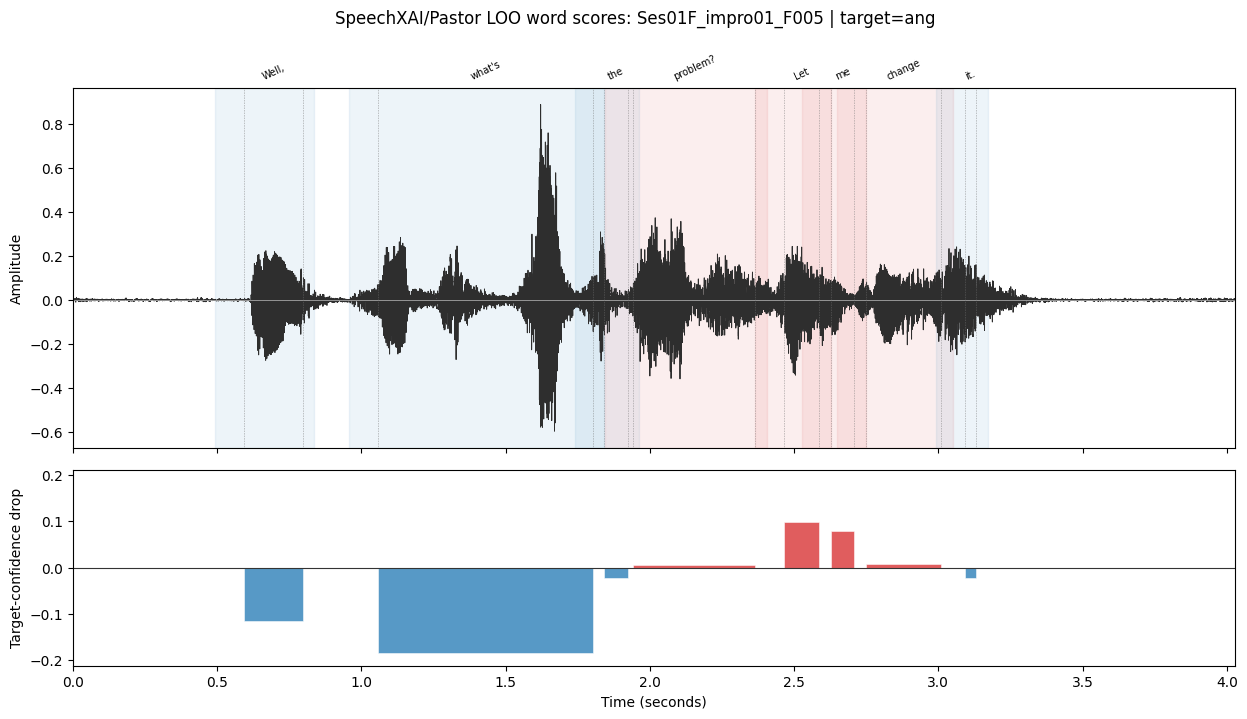

**Single-word removal shown below:** `Let`. The red span is the effective SpeechXAI mask, including the 100 ms before / 40 ms after padding.

,removed_word,word_start,word_end,masked_start,masked_end,masked_duration,masked_audio_percent,masked_samples,target_label,original_prediction,masked_prediction,original_confidence,masked_confidence,confidence_drop,relative_confidence_drop,prediction_flipped
0,Let,2.466,2.587,2.366,2.627,0.261,6.48,4176,ang,ang,hap,0.5195,0.4199,0.0996,0.1918,True


**Legend.** `removed_word` is the highest-scoring SpeechXAI/Pastor word; `word_start` and `word_end` are the original WhisperX word boundaries; `masked_start` and `masked_end` include the effective SpeechXAI padding; `masked_duration`, `masked_audio_percent`, and `masked_samples` quantify how much audio was silenced; prediction columns compare HuBERT before and after removal; confidence columns refer to the original target class; `prediction_flipped` indicates whether the predicted class changed.

C:\Users\mateu\AppData\Local\Temp\ipykernel_31188\24603600.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout(rect=[0, 0, 1, 0.95])


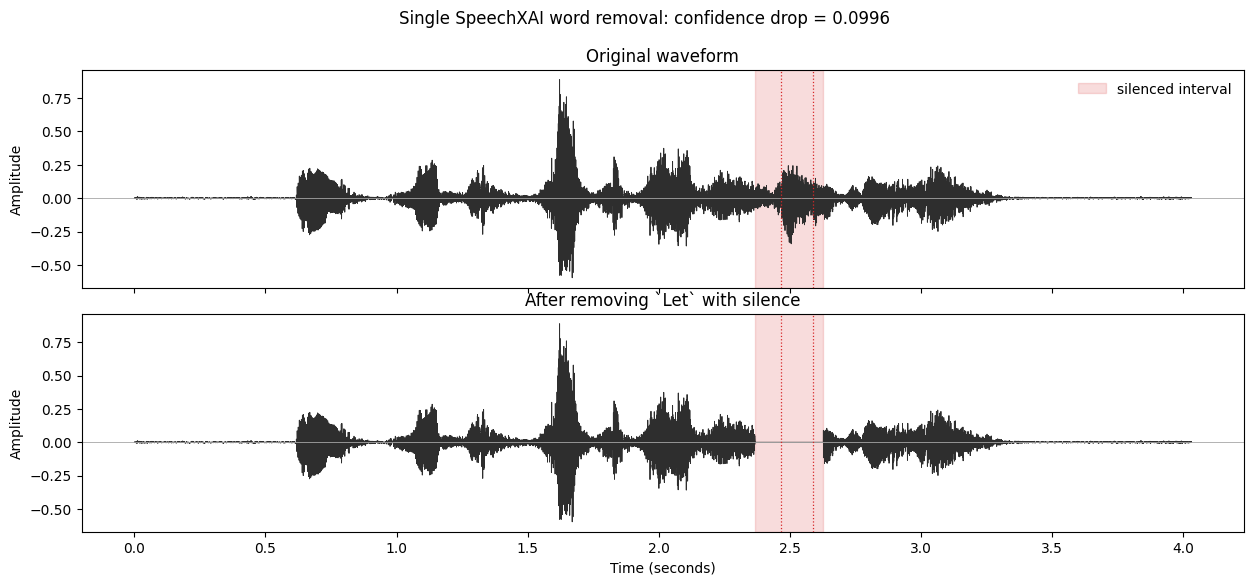

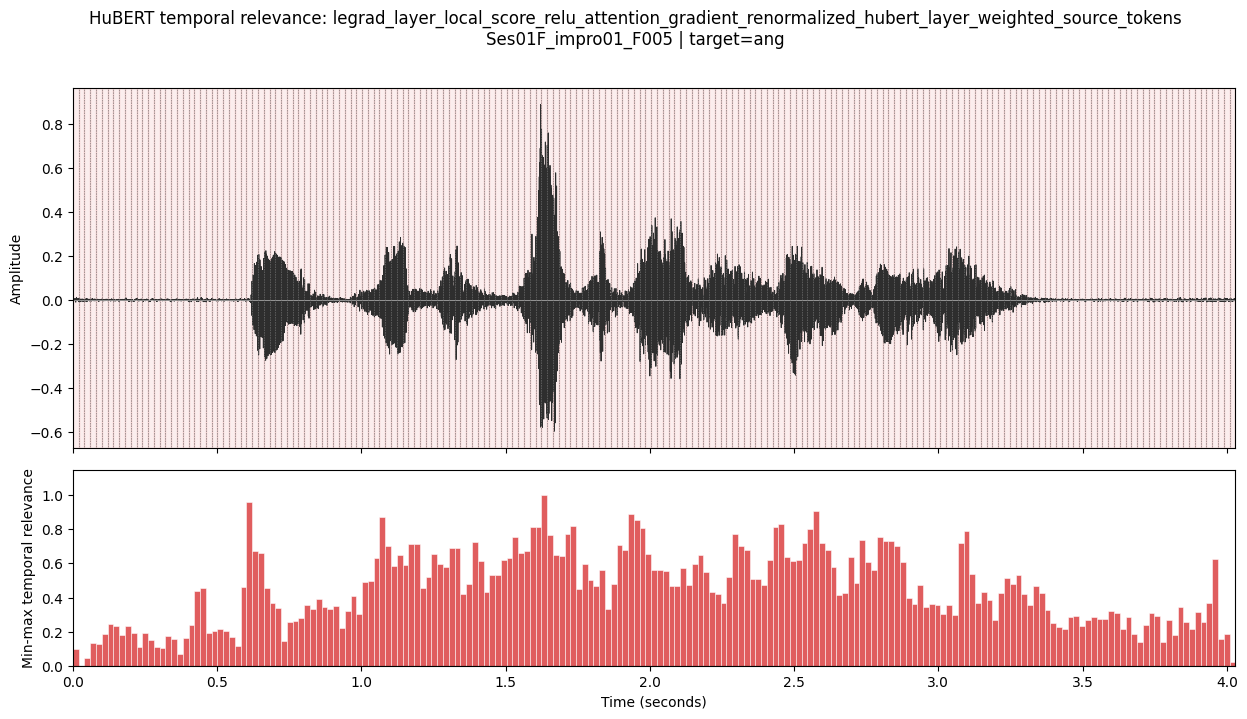

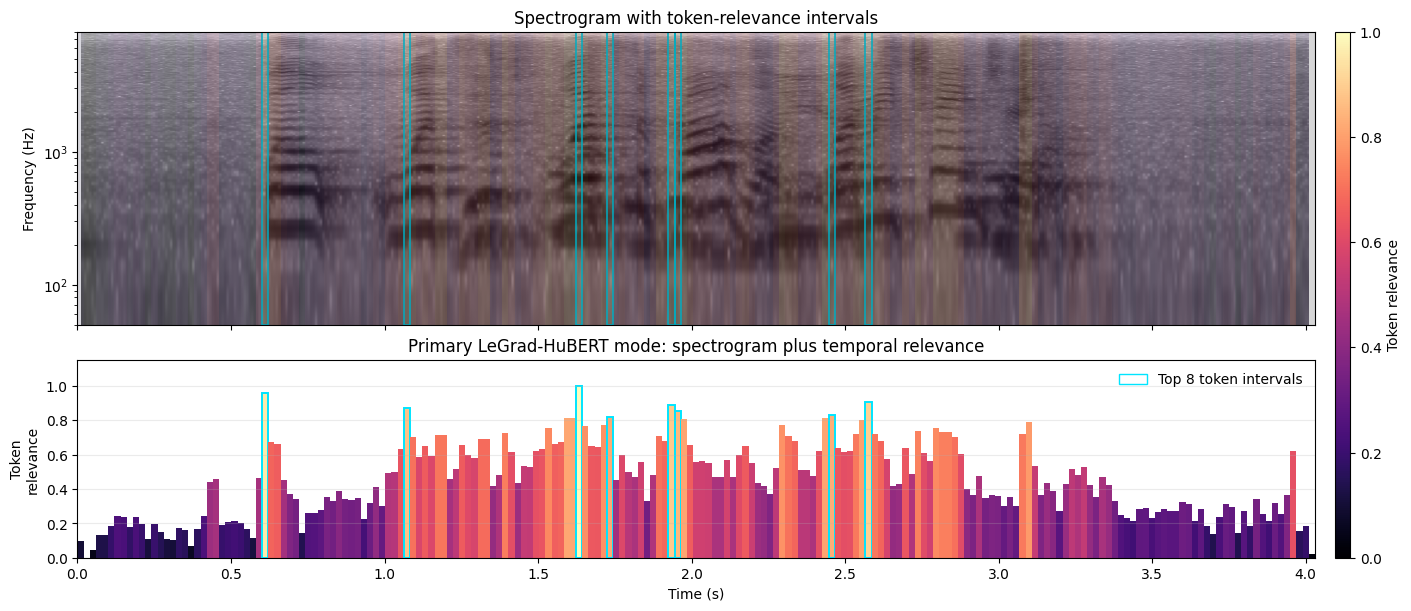

In [9]:
from src.speech_xai_project.masking import silence_intervals, total_interval_duration
import matplotlib.pyplot as plt

plot_waveform_with_interval_scores(
    waveform=waveform,
    sampling_rate=sampling_rate,
    intervals=result.speechxai_word_scores,
    score_column="score",
    start_column="start",
    end_column="end",
    label_column="word",
    masked_start_column="masked_start",
    masked_end_column="masked_end",
    title=(
        f"SpeechXAI/Pastor LOO word scores: {TARGET_AUDIO_ID} | "
        f"target={original_prediction.target_label}"
    ),
    score_label="Target-confidence drop",
)

removed_word_row = result.speechxai_word_scores.sort_values(
    "score",
    ascending=False,
).iloc[0]
removed_word_intervals = pd.DataFrame({
    "audio_id": [TARGET_AUDIO_ID],
    "start": [float(removed_word_row["masked_start"])],
    "end": [float(removed_word_row["masked_end"])],
    "score": [float(removed_word_row["score"])],
    "word": [str(removed_word_row["word"])],
})
removed_word_waveform = silence_intervals(
    waveform,
    sampling_rate,
    removed_word_intervals,
)
removed_word_prediction = classify_waveform(
    model,
    processor,
    removed_word_waveform,
    sampling_rate,
    device=DEVICE,
    target_class=original_prediction.target_class,
)

removed_duration = total_interval_duration(removed_word_intervals)
confidence_drop = original_prediction.target_confidence - removed_word_prediction.target_confidence
relative_drop = confidence_drop / original_prediction.target_confidence
start_sample = int(round(float(removed_word_row["masked_start"]) * sampling_rate))
end_sample = int(round(float(removed_word_row["masked_end"]) * sampling_rate))

removal_statistics = pd.DataFrame([
    {
        "removed_word": str(removed_word_row["word"]),
        "word_start": float(removed_word_row["start"]),
        "word_end": float(removed_word_row["end"]),
        "masked_start": float(removed_word_row["masked_start"]),
        "masked_end": float(removed_word_row["masked_end"]),
        "masked_duration": removed_duration,
        "masked_audio_percent": 100 * removed_duration / audio_duration,
        "masked_samples": max(0, end_sample - start_sample),
        "target_label": original_prediction.target_label,
        "original_prediction": original_prediction.predicted_label,
        "masked_prediction": removed_word_prediction.predicted_label,
        "original_confidence": original_prediction.target_confidence,
        "masked_confidence": removed_word_prediction.target_confidence,
        "confidence_drop": confidence_drop,
        "relative_confidence_drop": relative_drop,
        "prediction_flipped": removed_word_prediction.predicted_class != original_prediction.predicted_class,
    }
])

display(Markdown(
    f"**Single-word removal shown below:** `{removed_word_row['word']}`. "
    "The red span is the effective SpeechXAI mask, including the 100 ms before / 40 ms after padding."
))
display(removal_statistics.style.format({
    "word_start": "{:.3f}",
    "word_end": "{:.3f}",
    "masked_start": "{:.3f}",
    "masked_end": "{:.3f}",
    "masked_duration": "{:.3f}",
    "masked_audio_percent": "{:.2f}",
    "original_confidence": "{:.4f}",
    "masked_confidence": "{:.4f}",
    "confidence_drop": "{:.4f}",
    "relative_confidence_drop": "{:.4f}",
}))
display(Markdown(
    "**Legend.** `removed_word` is the highest-scoring SpeechXAI/Pastor word; `word_start` and "
    "`word_end` are the original WhisperX word boundaries; `masked_start` and `masked_end` include the "
    "effective SpeechXAI padding; `masked_duration`, `masked_audio_percent`, and `masked_samples` quantify "
    "how much audio was silenced; prediction columns compare HuBERT before and after removal; confidence "
    "columns refer to the original target class; `prediction_flipped` indicates whether the predicted class changed."
))

original_np = waveform.detach().cpu().numpy().squeeze()
removed_np = removed_word_waveform.detach().cpu().numpy().squeeze()
time_axis = np.arange(original_np.size) / sampling_rate
figure, axes = plt.subplots(
    2,
    1,
    figsize=(15, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12},
)
for axis, series, title in zip(
    axes,
    (original_np, removed_np),
    (
        "Original waveform",
        f"After removing `{removed_word_row['word']}` with silence",
    ),
):
    axis.plot(time_axis, series, color="0.18", linewidth=0.65)
    axis.axhline(0.0, color="0.65", linewidth=0.6)
    axis.axvspan(
        float(removed_word_row["masked_start"]),
        float(removed_word_row["masked_end"]),
        color="tab:red",
        alpha=0.16,
        label="silenced interval",
    )
    axis.axvline(float(removed_word_row["start"]), color="tab:red", linestyle=":", linewidth=0.9)
    axis.axvline(float(removed_word_row["end"]), color="tab:red", linestyle=":", linewidth=0.9)
    axis.set_ylabel("Amplitude")
    axis.set_title(title)
axes[-1].set_xlabel("Time (seconds)")
axes[0].legend(loc="upper right", frameon=False)
figure.suptitle(
    f"Single SpeechXAI word removal: confidence drop = {confidence_drop:.4f}",
    y=0.98,
)
figure.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
plt.close(figure)

primary_mode = LEGRAD_LAYER_LOCAL_SCORE_HUBERT_WEIGHTED_SOURCE_TOKENS
primary_table = result.relevance_tables[primary_mode].copy()

plot_waveform_with_interval_scores(
    waveform=waveform,
    sampling_rate=sampling_rate,
    intervals=primary_table,
    score_column="score",
    start_column="start",
    end_column="end",
    title=(
        f"HuBERT temporal relevance: {primary_mode}\n"
        f"{TARGET_AUDIO_ID} | target={original_prediction.target_label}"
    ),
    score_label="Min-max temporal relevance",
)

plot_relevance_timeline(
    waveform=waveform,
    sampling_rate=sampling_rate,
    df_relevance=primary_table.rename(columns={
        "start": "start_time",
        "end": "end_time",
        "score": "relevance",
    }),
    relevance_title="Primary LeGrad-HuBERT mode: spectrogram plus temporal relevance",
    top_k=8,
)

## Full-Dataset Command

The notebook proves the single-audio path. The full run is handled by `scripts/evaluate_duration_matched_speechxai.py`, which loops over IEMOCAP and RAVDESS, caches WhisperX word alignments, and writes the run tables documented in the README.